# Trabalho de Computação Distribuída

Este notebook contém a implementação da dedução analítica da disponibilidade e a simulação estocástica para os exercícios da disciplina.

### Funções Core

Abaixo são definidas as funções centrais. A função analítica utiliza `math.comb` para a distribuição binomial clássica. A função simulada emprega o método de Monte Carlo com matrizes do `numpy` (vetorização) para realizar milhares de rodadas simultaneamente, sem loops explícitos.

In [40]:
import math
import numpy as np
import matplotlib.pyplot as plt

def disp_analitica(n, k, p):
    """
    Calcula a disponibilidade analítica (probabilidade exata).
    Usa a distribuição binomial: somatório das probabilidades de ter
    de k a n nós funcionando.
    """
    probabilidade = 0.0
    for i in range(k, n + 1):
        probabilidade += math.comb(n, i) * (p ** i) * ((1 - p) ** (n - i))
    return probabilidade

def disp_simulada(n, k, p, rodadas=50):
    """
    Calcula a disponibilidade através do método de Monte Carlo de forma otimizada.
    Gera uma matriz de booleanos (rodadas x n) e avalia as condições vetorizadamente.
    """
    simulacoes = np.random.rand(rodadas, n) < p
    nos_disponiveis = np.sum(simulacoes, axis=1)
    sucessos = nos_disponiveis >= k
    return np.mean(sucessos)

def obter_regras_k(n):
    """
    Retorna um dicionário com o valor de k (nós necessários) para cada regra,
    dado um número total de nós n.
    """
    return {
        'Consulta (k=1)': 1,
        'Maioria (k=ceil(n/2))': math.ceil(n / 2),
        'Atualização (k=n)': n
    }

### Experimento 1

Neste experimento testamos o impacto da confiabilidade individual de um nó ($p$) na disponibilidade total do sistema.

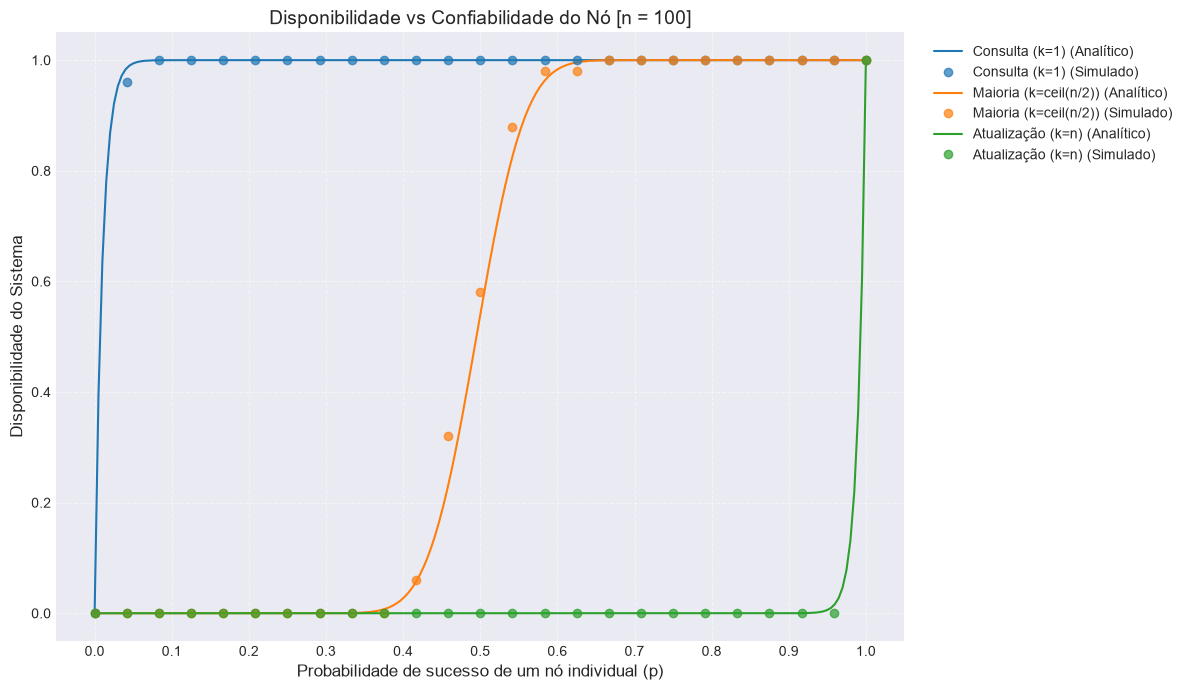

In [41]:
# Experimento 1: Avaliando 'p'

n_fixo = 100 
regras = obter_regras_k(n_fixo)

p_valores_analitico = np.linspace(0, 1, 200) 
p_valores_simulado = np.linspace(0, 1, 25)   

plt.figure(figsize=(12, 7))
cores = ['#1f77b4', '#ff7f0e', '#2ca02c'] 

for (nome_regra, k), cor in zip(regras.items(), cores):
    disp_a = [disp_analitica(n_fixo, k, p) for p in p_valores_analitico]
    plt.plot(p_valores_analitico, disp_a, color=cor, 
             label=f'{nome_regra} (Analítico)', zorder=2)
    
    disp_s = [disp_simulada(n_fixo, k, p, rodadas=50) for p in p_valores_simulado]
    plt.plot(p_valores_simulado, disp_s, marker='o', linestyle='', color=cor, 
             alpha=0.7, label=f'{nome_regra} (Simulado)', zorder=3)

plt.title(f'Disponibilidade vs Confiabilidade do Nó [n = {n_fixo}]', fontsize=14)
plt.xlabel('Probabilidade de sucesso de um nó individual (p)', fontsize=12)
plt.ylabel('Disponibilidade do Sistema', fontsize=12)
plt.xticks(np.arange(0, 1.1, 0.1)) 
plt.grid(True, linestyle='--', alpha=0.5, zorder=1)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Experimento 2: Escalabilidade do Sistema

Aqui avaliamos como o tamanho do cluster ($n$) impacta a disponibilidade, mantendo a probabilidade de sucesso fixa ($p=0.75$).
A curva analítica mostra o comportamento contínuo e exato, enquanto os marcadores representam as avaliações estocásticas do simulador.

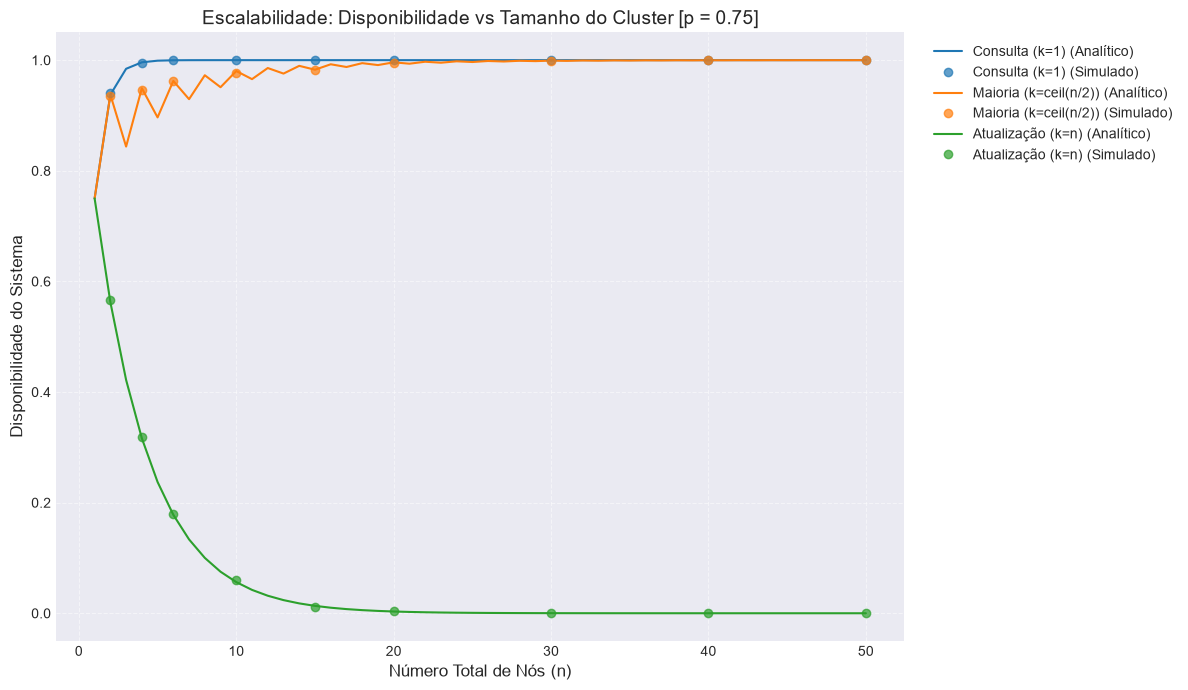

In [42]:
# Experimento 2: Escalabilidade do Sistema (Avaliando 'n')

p_fixo = 0.75
n_valores_analitico = np.arange(1, 51)
n_valores_simulado = np.array([2, 4, 6, 10, 15, 20, 30, 40, 50])

plt.figure(figsize=(12, 7))

regras_nomes = ['Consulta (k=1)', 'Maioria (k=ceil(n/2))', 'Atualização (k=n)']
cores = ['#1f77b4', '#ff7f0e', '#2ca02c']

for regra, cor in zip(regras_nomes, cores):
    # --- Dados Analíticos ---
    disp_a = []
    for n in n_valores_analitico:
        if 'Consulta' in regra:
            k = 1
        elif 'Maioria' in regra:
            k = math.ceil(n / 2)
        else: 
            k = n
        disp_a.append(disp_analitica(n, k, p_fixo))
        
    plt.plot(n_valores_analitico, disp_a, color=cor, 
             label=f'{regra} (Analítico)', zorder=2)
             
    # --- Dados Simulados ---
    disp_s = []
    for n in n_valores_simulado:
        if 'Consulta' in regra:
            k = 1
        elif 'Maioria' in regra:
            k = math.ceil(n / 2)
        else: 
            k = n
        disp_s.append(disp_simulada(n, k, p_fixo, rodadas=5000))
        
    plt.plot(n_valores_simulado, disp_s, marker='o', linestyle='', color=cor, 
             alpha=0.7, label=f'{regra} (Simulado)', zorder=3)

plt.title(f'Escalabilidade: Disponibilidade vs Tamanho do Cluster [p = {p_fixo}]', fontsize=14)
plt.xlabel('Número Total de Nós (n)', fontsize=12)
plt.ylabel('Disponibilidade do Sistema', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5, zorder=1)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Experimento 3: Evolução das Rodadas

Neste último teste, verificamos o princípio fundamental de Monte Carlo: a convergência.
Com $n=10$ e $p=0.75$ fixos, acompanhamos o comportamento da simulação conforme o número de rodadas aumenta. Em poucas rodadas o ruído estocástico é severo; em milhares de rodadas, a simulação se acomoda perfeitamente na probabilidade analítica exata (linha preta pontilhada).

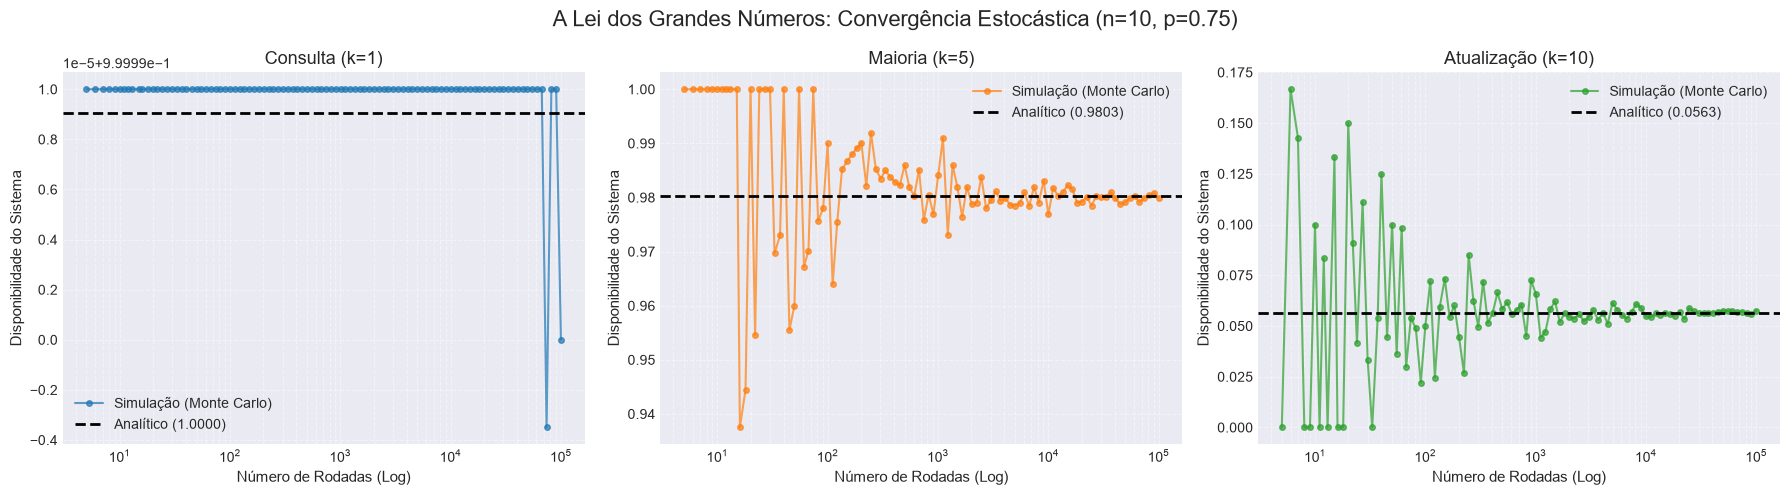

In [43]:
# Experimento 3: Evolução das Rodadas

n_fixo = 10
p_fixo = 0.75
k_regras = [1, 5, 10]
regras_titulos = ['Consulta (k=1)', 'Maioria (k=5)', 'Atualização (k=10)']
cores = ['#1f77b4', '#ff7f0e', '#2ca02c']

rodadas_array = np.unique(np.logspace(0.7, 5, 100).astype(int))

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)
fig.suptitle(f'A Lei dos Grandes Números: Convergência Estocástica (n={n_fixo}, p={p_fixo})', fontsize=16)

for ax, k, titulo, cor in zip(axes, k_regras, regras_titulos, cores):
    referencia_analitica = disp_analitica(n_fixo, k, p_fixo)
    valores_simulados = [disp_simulada(n_fixo, k, p_fixo, rodadas) for rodadas in rodadas_array]
    
    ax.plot(rodadas_array, valores_simulados, marker='o', markersize=4, linestyle='-', 
             color=cor, alpha=0.7, label='Simulação (Monte Carlo)')
    
    ax.axhline(y=referencia_analitica, color='black', linestyle='--', linewidth=2, 
                label=f'Analítico ({referencia_analitica:.4f})')
    
    ax.set_title(titulo, fontsize=13)
    ax.set_xlabel('Número de Rodadas (Log)', fontsize=11)
    ax.set_ylabel('Disponibilidade do Sistema', fontsize=11)
    ax.set_xscale('log')
    ax.grid(True, which='both', linestyle='--', alpha=0.4)
    ax.legend(fontsize=10)

plt.tight_layout()
plt.show()